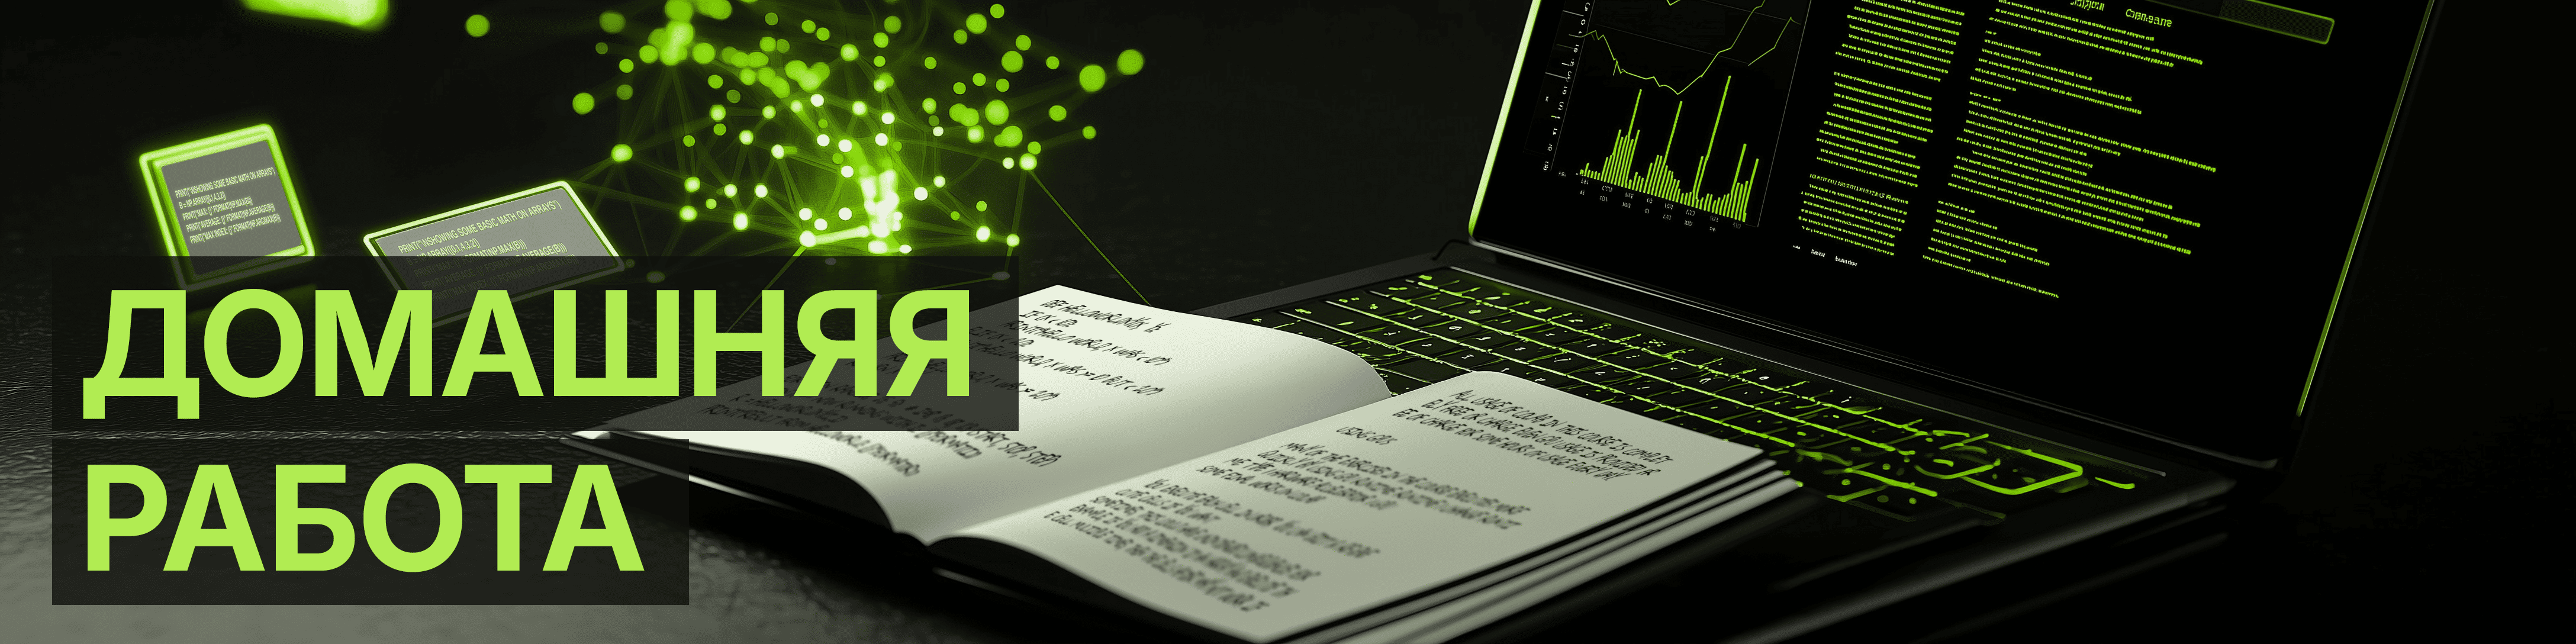

**Навигация по уроку**

1. [Введение в сверточные нейронные сети](https://colab.research.google.com/drive/10cBnEfHhZlv3ZhEgVimA3GqSEZtvqpTv)
2. [Обучение сверточной нейронной сети на ограниченном наборе данных](https://colab.research.google.com/drive/1e1aZ9K1vQIujPf1mzmta5xtbfNqJ_ai-)
3. [Предобученные сверточные НС](https://colab.research.google.com/drive/12VehrJe062P9QImtvjILQG0DOLooiyk0)
4. Домашняя работа

В данном домашнем задании вам необходимо:

1. Используйте датасет "Собаки и кошки", рассмотренный в данном уроке. Причем используйте его целиком, а не только 4000 изображений.
2. Проведите аугментацию изображений.
3. В качестве предобученной модели возьмите `MobileNet`
4. Создайте модель, приведенную ниже.
5. Обучите модель и проверьте на тестовой выборке.
6. Если модель не обеспечивает заданную точность - "поиграйтесь" с гиперпараметрами.


Для получения 3 баллов за задание необходимо достичь на контрольной выборке точности 90%, 4 баллов -  более 93%, 5 баллов - более 95%.

На 20 тыс. изображений данная модель выдавала нам результат 99%.

**Подсказка**. Обратите внимание, что предлагаемая модель уже не является бинарной классификацией. Это уже задача многоклассовой классификации (в нашем случае 2 класса). А значит в генераторах изображений необходимо использовать:

```pyton
class_mode='categorical'
```

Также необходимо вспомнить какую функцию ошибки использовать с задачей многоклассовой классификации. Можно попробовать в качестве оптимизатора использовать Adam с разными шагами.

Также обратите внимание, что вместо слоя `Flatten()`, вам предлагается использовать `GlobalAveragePooling2D()` (https://keras.io/api/layers/pooling_layers/global_average_pooling2d/).


In [ ]:
from keras.applications import MobileNet
from keras import models
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras import optimizers

def model_maker():
    base_model = MobileNet(include_top=False, input_shape = (IMG_WIDTH, IMG_HEIGHT, 3))

    for layer in base_model.layers[:]:
        layer.trainable = False

    input = Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))
    custom_model = base_model(input)
    custom_model = GlobalAveragePooling2D()(custom_model)
    custom_model = Dense(64, activation='relu')(custom_model)
    custom_model = Dropout(0.5)(custom_model)
    predictions = Dense(NUM_CLASSES, activation='softmax')(custom_model)

    return Model(inputs=input, outputs=predictions)

In [ ]:
model_maker.summary()

In [ ]:
# импорт
!pip -q install split-folders

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import splitfolders

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: []


In [ ]:
# параметры
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32
NUM_CLASSES = 2

ZIP_URL = "https://storage.yandexcloud.net/academy.ai/cat-and-dog.zip"
ZIP_NAME = "cat-and-dog.zip"

RAW_DIR = "./temp"
IMAGE_PATH = "./temp/training_set/training_set/"
BASE_DIR = "./dataset_full"

print("IMG:", IMG_WIDTH, IMG_HEIGHT)
print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_CLASSES:", NUM_CLASSES)

IMG: 224 224
BATCH_SIZE: 32
NUM_CLASSES: 2


In [ ]:
# датасет
if not os.path.exists(ZIP_NAME):
    !wget -O {ZIP_NAME} {ZIP_URL}

if os.path.exists(RAW_DIR):
    shutil.rmtree(RAW_DIR)

!unzip -qo {ZIP_NAME} -d {RAW_DIR}

print("Папки классов:", os.listdir(IMAGE_PATH))

--2026-03-15 07:35:36--  https://storage.yandexcloud.net/academy.ai/cat-and-dog.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228082266 (218M) [application/x-zip-compressed]
Saving to: ‘cat-and-dog.zip’

cat-and-dog.zip     100%[===================>] 217.52M  25.0MB/s    in 9.6s    

2026-03-15 07:35:46 (22.7 MB/s) - ‘cat-and-dog.zip’ saved [228082266/228082266]

Папки классов: ['dogs', 'cats']


In [ ]:
# проверка количества файлов
class_list = sorted(os.listdir(IMAGE_PATH))
print("CLASS_LIST:", class_list)

for cls in class_list:
    cls_path = os.path.join(IMAGE_PATH, cls)
    files = os.listdir(cls_path)
    print(f"{cls}: {len(files)}")

CLASS_LIST: ['cats', 'dogs']
cats: 4000
dogs: 4005


In [ ]:
# разбиение датасета
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

# 70% train, 15% validation, 15% test
splitfolders.ratio(
    IMAGE_PATH,
    output=BASE_DIR,
    seed=SEED,
    ratio=(0.70, 0.15, 0.15),
    group_prefix=None
)

train_dir = os.path.join(BASE_DIR, "train")
validation_dir = os.path.join(BASE_DIR, "val")
test_dir = os.path.join(BASE_DIR, "test")

print("train_dir:", train_dir)
print("validation_dir:", validation_dir)
print("test_dir:", test_dir)

for part_name, part_dir in [("train", train_dir), ("validation", validation_dir), ("test", test_dir)]:
    print(f"\n{part_name.upper()}:")
    total = 0
    for cls in class_list:
        count = len(os.listdir(os.path.join(part_dir, cls)))
        total += count
        print(f"  {cls}: {count}")
    print("  total:", total)

Copying files: 8005 files [00:02, 3978.02 files/s]

train_dir: ./dataset_full/train
validation_dir: ./dataset_full/val
test_dir: ./dataset_full/test

TRAIN:
  cats: 2800
  dogs: 2803
  total: 5603

VALIDATION:
  cats: 600
  dogs: 600
  total: 1200

TEST:
  cats: 600
  dogs: 602
  total: 1202


In [ ]:
# генераторы изображений
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("class_indices:", train_generator.class_indices)

Found 5603 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.
Found 1202 images belonging to 2 classes.
class_indices: {'cats': 0, 'dogs': 1}


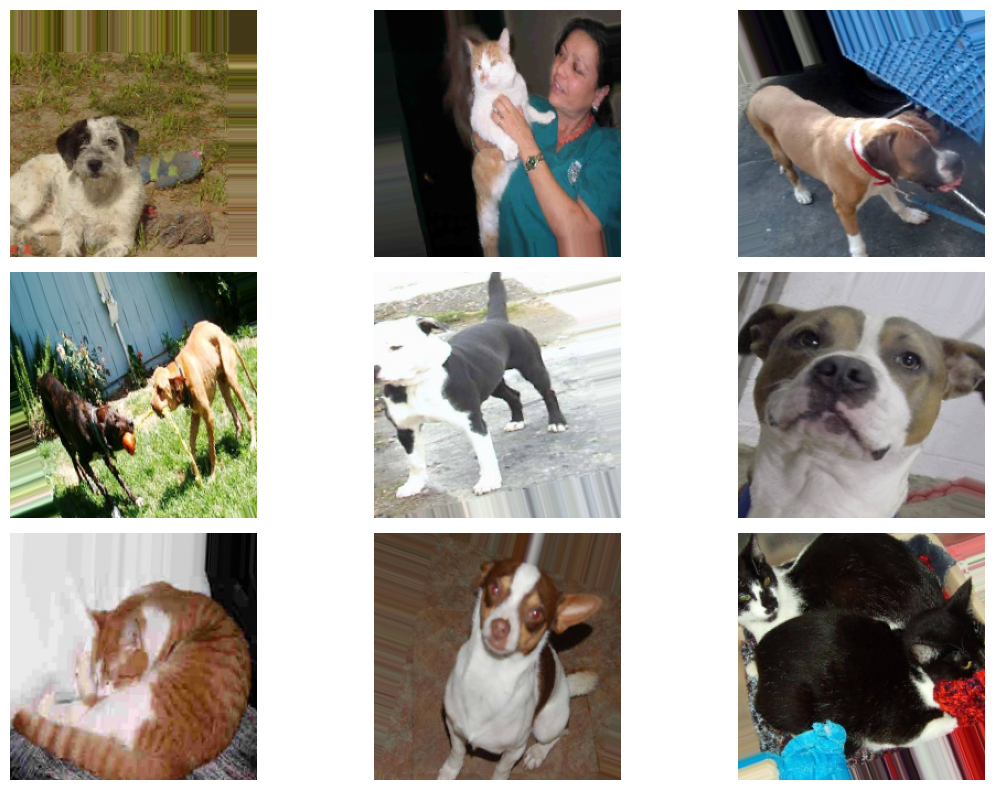

In [ ]:
# просмотр аугментации
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = x_batch[i]
    img = (img + 1.0) / 2.0  # приблизительно обратно после preprocess_input MobileNet
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# модель MobileNet
def model_maker():
    base_model = MobileNet(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    inputs = Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model

model, base_model = model_maker()
model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,294,594 (12.57 MB)

 Trainable params: 65,730 (256.76 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
# компиляция модели
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_mobilenet_stage1.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# обучение только “головы”
history_stage1 = model.fit(
    train_generator,
    epochs=12,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8816 - loss: 0.2773
Epoch 1: val_accuracy improved from None to 0.97750, saving model to best_mobilenet_stage1.keras

Epoch 1: finished saving model to best_mobilenet_stage1.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9363 - loss: 0.1581 - val_accuracy: 0.9775 - val_loss: 0.0518 - learning_rate: 0.0010
Epoch 2/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9735 - loss: 0.0728
Epoch 2: val_accuracy improved from 0.97750 to 0.98000, saving model to best_mobilenet_stage1.keras

Epoch 2: finished saving model to best_mobilenet_stage1.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.9743 - loss: 0.0705 - val_accuracy: 0.9800 - val_loss: 0.0473 - learning_rate: 0.0010
Epoch 3/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9725 - loss: 0.0662
Epoch 3: val_accuracy improved from 0.98000 to 0.98417, saving model to best_mobilenet_stage1.keras

Epoch 3: finished saving model to bes

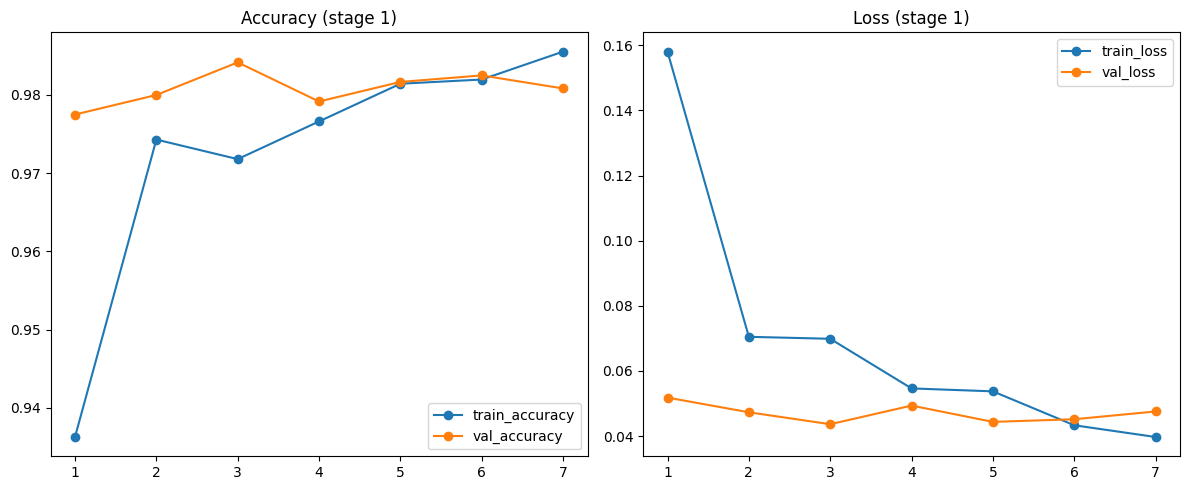

In [ ]:
# графики
def plot_history(history, title_suffix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, "o-", label="train_accuracy")
    plt.plot(epochs, val_acc, "o-", label="val_accuracy")
    plt.title(f"Accuracy {title_suffix}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, "o-", label="train_loss")
    plt.plot(epochs, val_loss, "o-", label="val_loss")
    plt.title(f"Loss {title_suffix}")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_stage1, "(stage 1)")

In [ ]:
# fine-tuning верхних слоёв MobileNet
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "best_mobilenet_finetuned.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_stage2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=callbacks_ft,
    verbose=1
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9766 - loss: 0.0623
Epoch 1: val_accuracy improved from None to 0.98333, saving model to best_mobilenet_finetuned.keras

Epoch 1: finished saving model to best_mobilenet_finetuned.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9780 - loss: 0.0568 - val_accuracy: 0.9833 - val_loss: 0.0432 - learning_rate: 1.0000e-05
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9802 - loss: 0.0537
Epoch 2: val_accuracy did not improve from 0.98333
176/176 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9788 - loss: 0.0546 - val_accuracy: 0.9825 - val_loss: 0.0434 - learning_rate: 1.0000e-05
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9790 - loss: 0.0556
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.98333
176/176 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.9795 - loss: 0.0529 - val_accuracy: 0.9825 - val_los

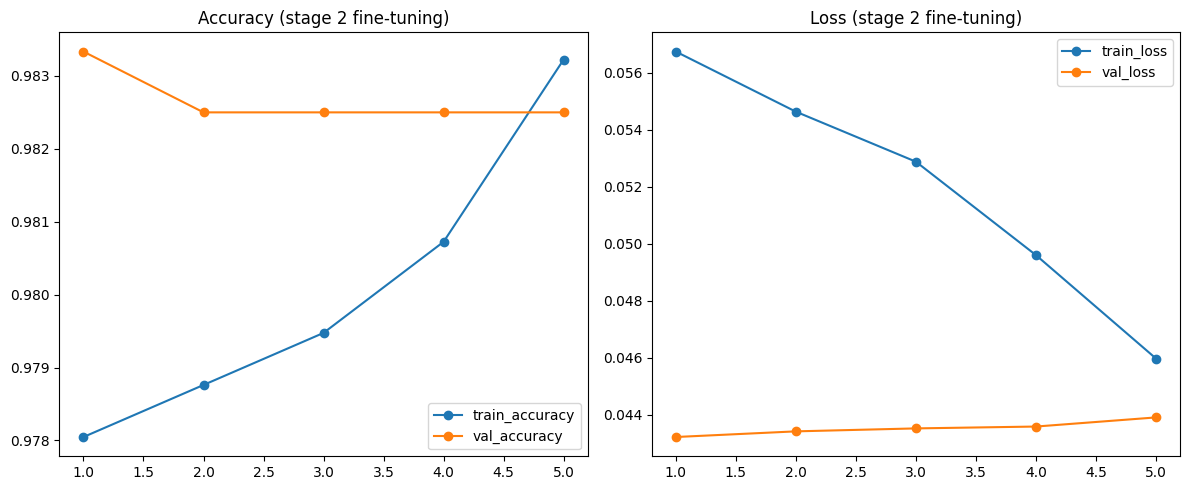

In [ ]:
# графики
plot_history(history_stage2, "(stage 2 fine-tuning)")

In [ ]:
# оценка на validation и test
val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9833 - loss: 0.0432
38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9792 - loss: 0.0497
Validation accuracy: 0.9833
Test accuracy: 0.9792


In [ ]:
# проверка условий
print("Проверка условий:")
print(f"1) test_accuracy >= 0.90 --> {'PASS' if test_acc >= 0.90 else 'FAIL'} ({test_acc:.4f})")
print(f"2) test_accuracy > 0.93  --> {'PASS' if test_acc > 0.93 else 'FAIL'} ({test_acc:.4f})")
print(f"3) test_accuracy > 0.95  --> {'PASS' if test_acc > 0.95 else 'FAIL'} ({test_acc:.4f})")

Проверка условий:
1) test_accuracy >= 0.90 --> PASS (0.9792)
2) test_accuracy > 0.93  --> PASS (0.9792)
3) test_accuracy > 0.95  --> PASS (0.9792)


In [ ]:
# несколько предсказаний на test
test_generator.reset()
pred_probs = model.predict(test_generator, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("Первые 10 предсказаний:")
for i in range(10):
    pred_label = class_names[pred_classes[i]]
    true_label = class_names[true_classes[i]]
    confidence = pred_probs[i][pred_classes[i]]
    print(f"{i+1:02d}. pred={pred_label}, true={true_label}, prob={confidence:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step
Первые 10 предсказаний:
01. pred=cats, true=cats, prob=1.0000
02. pred=cats, true=cats, prob=0.9998
03. pred=cats, true=cats, prob=1.0000
04. pred=cats, true=cats, prob=0.9999
05. pred=cats, true=cats, prob=0.9999
06. pred=cats, true=cats, prob=1.0000
07. pred=cats, true=cats, prob=1.0000
08. pred=cats, true=cats, prob=1.0000
09. pred=cats, true=cats, prob=1.0000
10. pred=cats, true=cats, prob=1.0000


In [ ]:
# сохранение модели
model.save("cats_dogs_mobilenet_final.keras")
print("Модель сохранена: cats_dogs_mobilenet_final.keras")

Модель сохранена: cats_dogs_mobilenet_final.keras


ОТЧЁТ

В работе использован полный датасет «Собаки и кошки», а не сокращённый набор из 4000 изображений.
Для повышения обобщающей способности модели применена аугментация изображений.
В качестве предобученной сети использована MobileNet, как требуется в условии задания.

Архитектура модели:
- MobileNet без верхнего классификатора (include_top=False)
- GlobalAveragePooling2D
- Dense(64, activation='relu')
- Dropout(0.5)
- Dense(NUM_CLASSES, activation='softmax')

Так как задача оформлена как многоклассовая классификация с двумя классами,
в генераторах использовался class_mode='categorical',
а в качестве функции потерь — categorical_crossentropy.

Результаты:
- accuracy на validation: 0.9833
- accuracy на test: 0.9792